In [51]:
#import libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import shap
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
import time

In [52]:
file_path = "/content/Predicting Energy Consumption.xlsm"

df = pd.read_excel(file_path)

df.head()




,Start time UTC,End time UTC,Electricity consumption (MWh)
0,2015-12-31 21:00:00,2015-12-31 22:00:00,10800
1,2015-12-31 22:00:00,2015-12-31 23:00:00,10431
2,2015-12-31 23:00:00,2016-01-01 00:00:00,10005
3,2016-01-01 00:00:00,2016-01-01 01:00:00,9722
4,2016-01-01 01:00:00,2016-01-01 02:00:00,9599


In [53]:
#Data preprocessing

df['Start time UTC'] = pd.to_datetime(df['Start time UTC'])
df = df.sort_values('Start time UTC').set_index('Start time UTC')
df = df.drop(columns=['End time UTC'])
df.interpolate(method='time', inplace=True)


In [54]:
# Check missing values
df.isnull().sum()

,0
Electricity consumption (MWh),0


In [55]:
# Time-based interpolation (safe for energy data)
df.interpolate(method='time', inplace=True)

In [56]:
rolling_mean = df['Electricity consumption (MWh)'].rolling(24).mean()
rolling_std = df['Electricity consumption (MWh)'].rolling(24).std()

upper_bound = rolling_mean + 3 * rolling_std
lower_bound = rolling_mean - 3 * rolling_std

outliers = (df['Electricity consumption (MWh)'] > upper_bound) | \
           (df['Electricity consumption (MWh)'] < lower_bound)

df.loc[outliers, 'Electricity consumption (MWh)'] = rolling_mean[outliers]

/tmp/ipython-input-3563194170.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[ 8913.54166667  8141.83333333  7760.875       9666.
  9088.          8566.95833333 11882.91666667 10433.70833333
 10528.79166667  9239.58333333  8469.29166667  8829.33333333
  8750.45833333  8862.125       8772.91666667  8439.83333333
  8871.04166667  8768.45833333  8454.          8701.66666667
  8669.125       8612.58333333  8507.75        8799.91666667
  8699.91666667  8730.66666667  8622.54166667  8963.20833333
  8992.25        8996.25        9000.33333333  9016.875
  9056.83333333  8416.375       8370.66666667  8257.83333333
  8772.33333333]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[outliers, 'Electricity consumption (MWh)'] = rolling_mean[outliers]


In [57]:
df['hour'] = df.index.hour
df['dayofweek'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)

In [58]:
df['lag_1'] = df['Electricity consumption (MWh)'].shift(1)
df['lag_24'] = df['Electricity consumption (MWh)'].shift(24)
df['lag_168'] = df['Electricity consumption (MWh)'].shift(168)

In [59]:
df['rolling_mean_24'] = df['Electricity consumption (MWh)'].rolling(24).mean()
df['rolling_mean_168'] = df['Electricity consumption (MWh)'].rolling(168).mean()
df['rolling_std_24'] = df['Electricity consumption (MWh)'].rolling(24).std()

In [60]:
df.dropna(inplace=True)

In [61]:
# Train-test split
split = int(len(df) * 0.8)
train, test = df.iloc[:split], df.iloc[split:]

X_train = train.drop(columns=['Electricity consumption (MWh)'])
y_train = train['Electricity consumption (MWh)']
X_test = test.drop(columns=['Electricity consumption (MWh)'])
y_test = test['Electricity consumption (MWh)']

In [62]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=150, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}

results = []

In [67]:
# Training & Evaluation
for name, model in models.items():
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, mae, rmse, train_time])


In [68]:
# Results table
results_df = pd.DataFrame(
    results,
    columns=["Model", "MAE (MWh)", "RMSE (MWh)", "Training Time (sec)"]
)

results_df

,Model,MAE (MWh),RMSE (MWh),Training Time (sec)
0,Linear Regression,137.979906,181.056583,0.016395
1,Random Forest,83.653005,120.936566,60.599382
2,Gradient Boosting,96.641556,132.900666,13.418695
3,XGBoost,80.425023,113.304544,1.538567
4,Linear Regression,137.979906,181.056583,0.012231
5,Random Forest,83.653005,120.936566,59.048216
6,Gradient Boosting,96.641556,132.900666,18.832364
7,XGBoost,80.425023,113.304544,1.424319


In [69]:
# Select best model based on lowest MAE
best_model_name = results_df.loc[
    results_df["MAE (MWh)"].idxmin(), "Model"
]

print("Best Model based on MAE:", best_model_name)

Best Model based on MAE: XGBoost


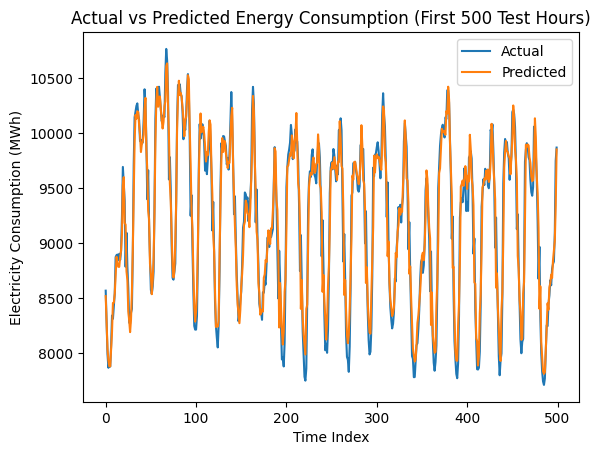

In [64]:
# Graphs, Confusion Matrix, and SHAP analysis for the trained model
# Actual vs Predicted Plot
plt.figure()
plt.plot(y_test.values[:500], label="Actual")
plt.plot(y_pred[:500], label="Predicted")
plt.title("Actual vs Predicted Energy Consumption (First 500 Test Hours)")
plt.xlabel("Time Index")
plt.ylabel("Electricity Consumption (MWh)")
plt.legend()
plt.show()



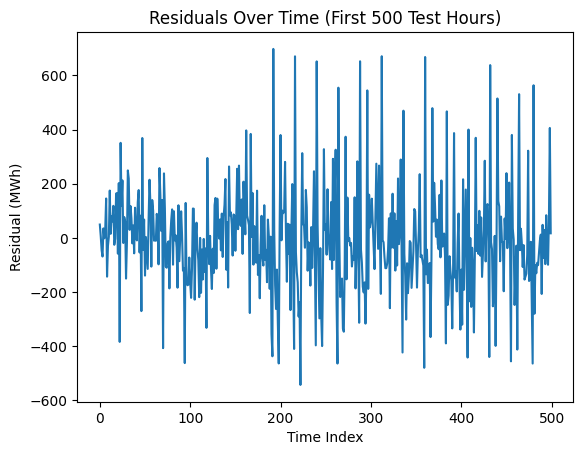

In [65]:
# Residual Plot
residuals = y_test.values - y_pred
plt.figure()
plt.plot(residuals[:500])
plt.title("Residuals Over Time (First 500 Test Hours)")
plt.xlabel("Time Index")
plt.ylabel("Residual (MWh)")
plt.show()




100%|===================| 10557/10560 [03:09<00:00]       

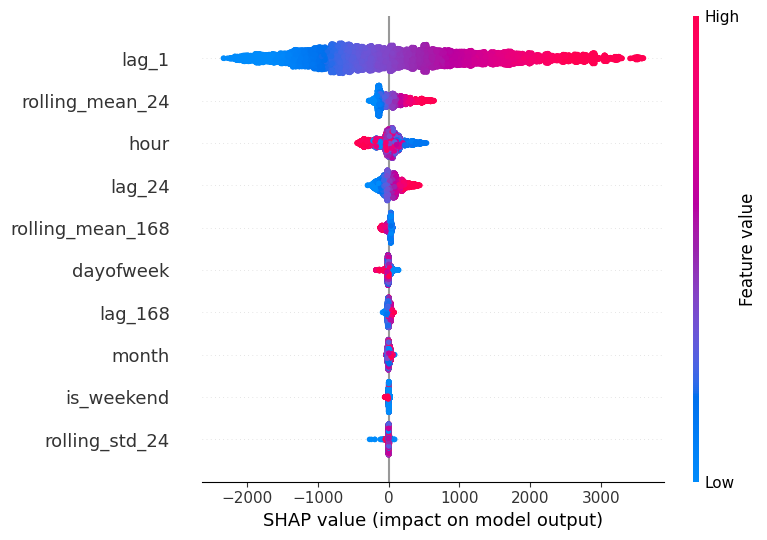

In [72]:
# SHAP Analysis
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# SHAP summary plot
shap.summary_plot(shap_values, X_test, show=True)